# Pima Indians Diabetes 데이터셋 EDA

목표: `Outcome`(당뇨 여부)을 예측하는 트리 기반 모델을 만들기 전에 데이터 구조, 분포, 이상 패턴을 파악한다.

## 0. 환경 설정 & 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

df = pd.read_csv('diabetes.csv')
df.shape

Matplotlib is building the font cache; this may take a moment.


(768, 9)

In [2]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure               float64
SkinThickness                 int64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


## 1. 기초 통계 & 결측치/이상값 점검

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,121.677083,30.464161,44.000,99.75000,117.0000,140.25000,199.00
BloodPressure,768.0,72.389323,12.106039,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,768.0,29.089844,8.890820,7.000,25.00000,28.0000,32.00000,99.00
Insulin,768.0,141.753906,89.100847,14.000,102.50000,102.5000,169.50000,846.00
BMI,768.0,32.434635,6.880498,18.200,27.50000,32.0500,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


### 컬럼별 0값 개수
`Pregnancies`는 0이 정상값(임신 0회)이지만, 나머지 피처의 0은 임상적으로 불가능한 값이라 결측치일 가능성이 있다. 이 데이터셋이 이미 전처리되었는지 확인한다.

In [6]:
zero_counts = (df == 0).sum()
zero_counts

Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [7]:
print('중복 행 수:', df.duplicated().sum())
print('결측값(NaN) 개수:')
print(df.isnull().sum())

중복 행 수: 0
결측값(NaN) 개수:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


### Insulin / SkinThickness 임퓨테이션 스파이크 확인
`Insulin`과 `SkinThickness`는 특정 값이 비정상적으로 많이 반복되는지 확인한다. 이는 원래 결측치(0)를 평균/중앙값 등으로 대체(임퓨테이션)한 흔적일 수 있다.

In [8]:
print('Insulin top values:')
print(df['Insulin'].value_counts().head(5))
print()
print('SkinThickness top values:')
print(df['SkinThickness'].value_counts().head(5))

Insulin top values:
Insulin
102.5    236
169.5    138
105.0     11
130.0      9
140.0      9
Name: count, dtype: int64

SkinThickness top values:
SkinThickness
27    162
32    119
30     27
23     22
28     20
Name: count, dtype: int64


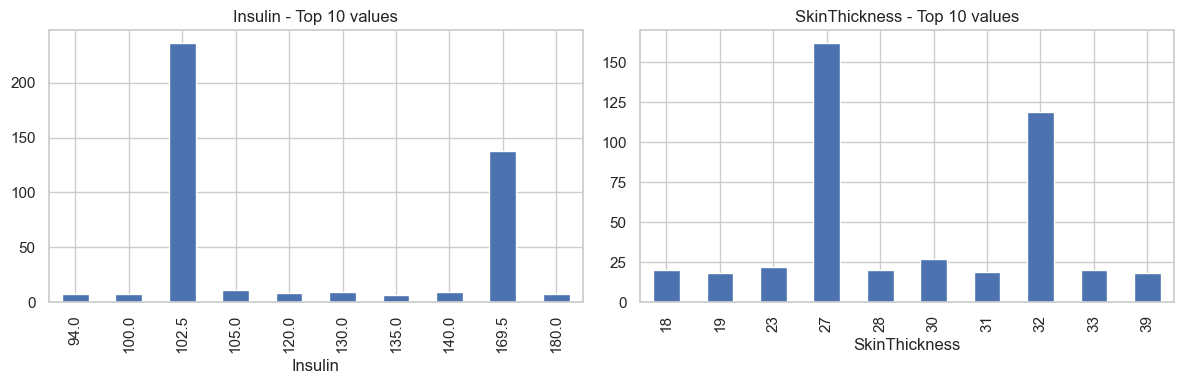

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['Insulin'].value_counts().head(10).sort_index().plot(kind='bar', ax=axes[0], title='Insulin - Top 10 values')
df['SkinThickness'].value_counts().head(10).sort_index().plot(kind='bar', ax=axes[1], title='SkinThickness - Top 10 values')
plt.tight_layout()
plt.show()

> 특정 값(예: Insulin=102.5, 169.5 / SkinThickness=27, 32)이 다른 값보다 훨씬 많이 등장한다면, 이는 실제 생리학적 분포가 아니라 결측치를 대체한 인위적인 스파이크일 가능성이 높다. 뒤쪽 히스토그램에서도 해당 값 위치에 뾰족한 막대로 나타나는지 확인한다. 모델링 단계에서 이 점을 유의해야 한다 (예: 임퓨테이션 플래그 피처 추가를 고려할 수 있음).

## 2. 타겟 변수(Outcome) 분포

Outcome
0    500
1    268
Name: count, dtype: int64
비율 -> 0(비당뇨): 65.1%, 1(당뇨): 34.9%


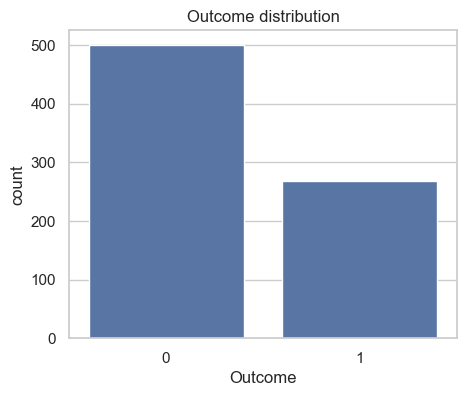

In [10]:
outcome_counts = df['Outcome'].value_counts().sort_index()
print(outcome_counts)
print(f"비율 -> 0(비당뇨): {outcome_counts[0]/len(df):.1%}, 1(당뇨): {outcome_counts[1]/len(df):.1%}")

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='Outcome')
plt.title('Outcome distribution')
plt.show()

> 약 65:35 비율의 중간 정도 클래스 불균형이 있다. 이후 트리 모델 학습 시 `class_weight='balanced'` 적용이나 정확도 외 F1-score/AUC 같은 평가지표 사용을 고려한다.

## 3. 단변량 분포 (Univariate)

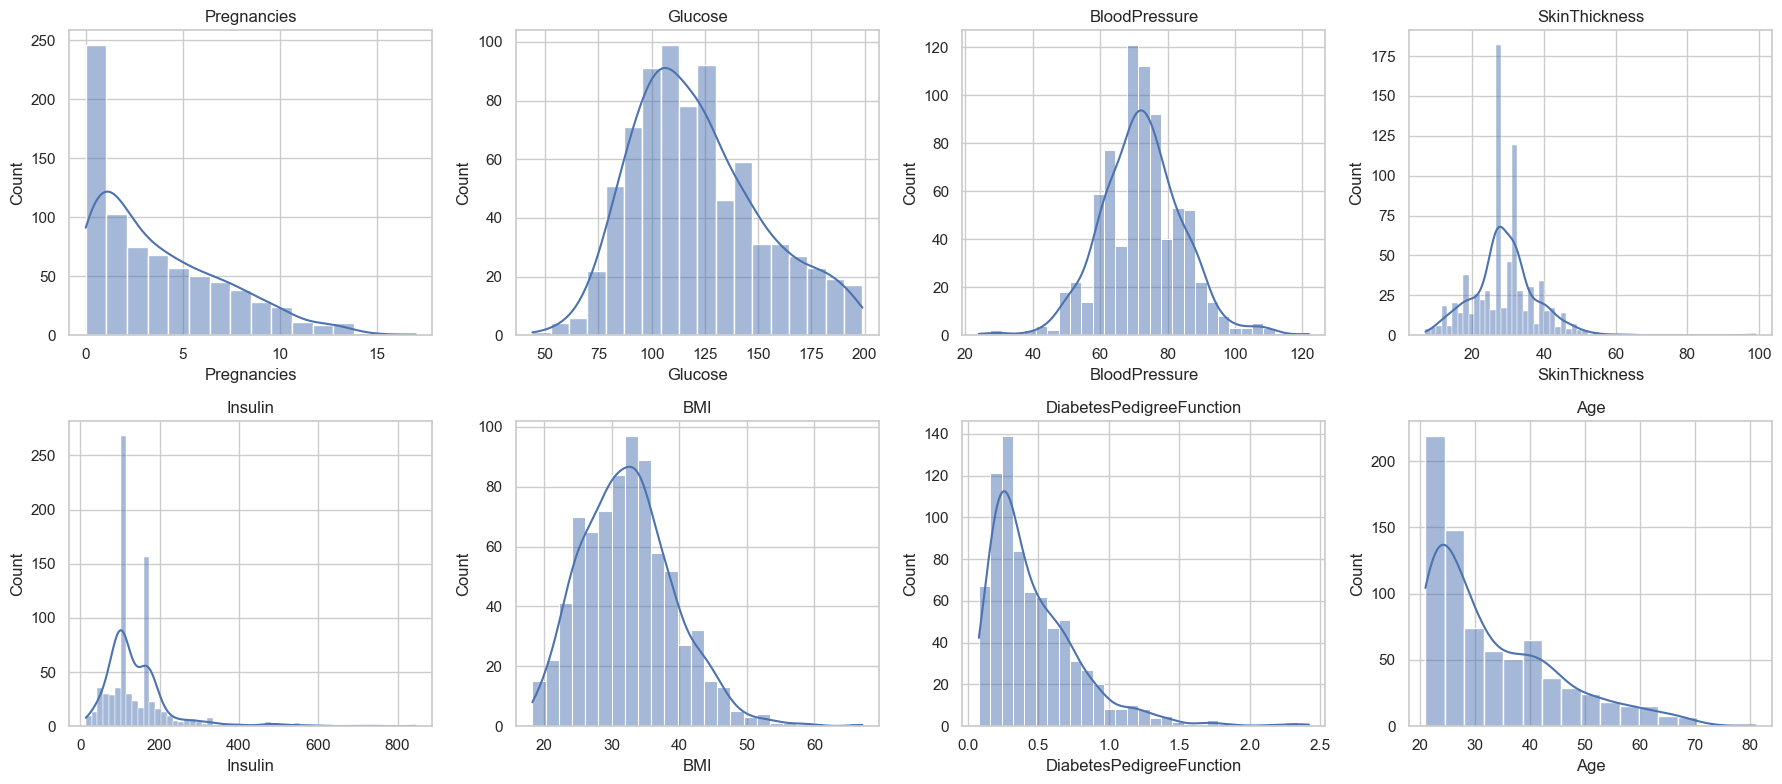

In [11]:
features = [c for c in df.columns if c != 'Outcome']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), features):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

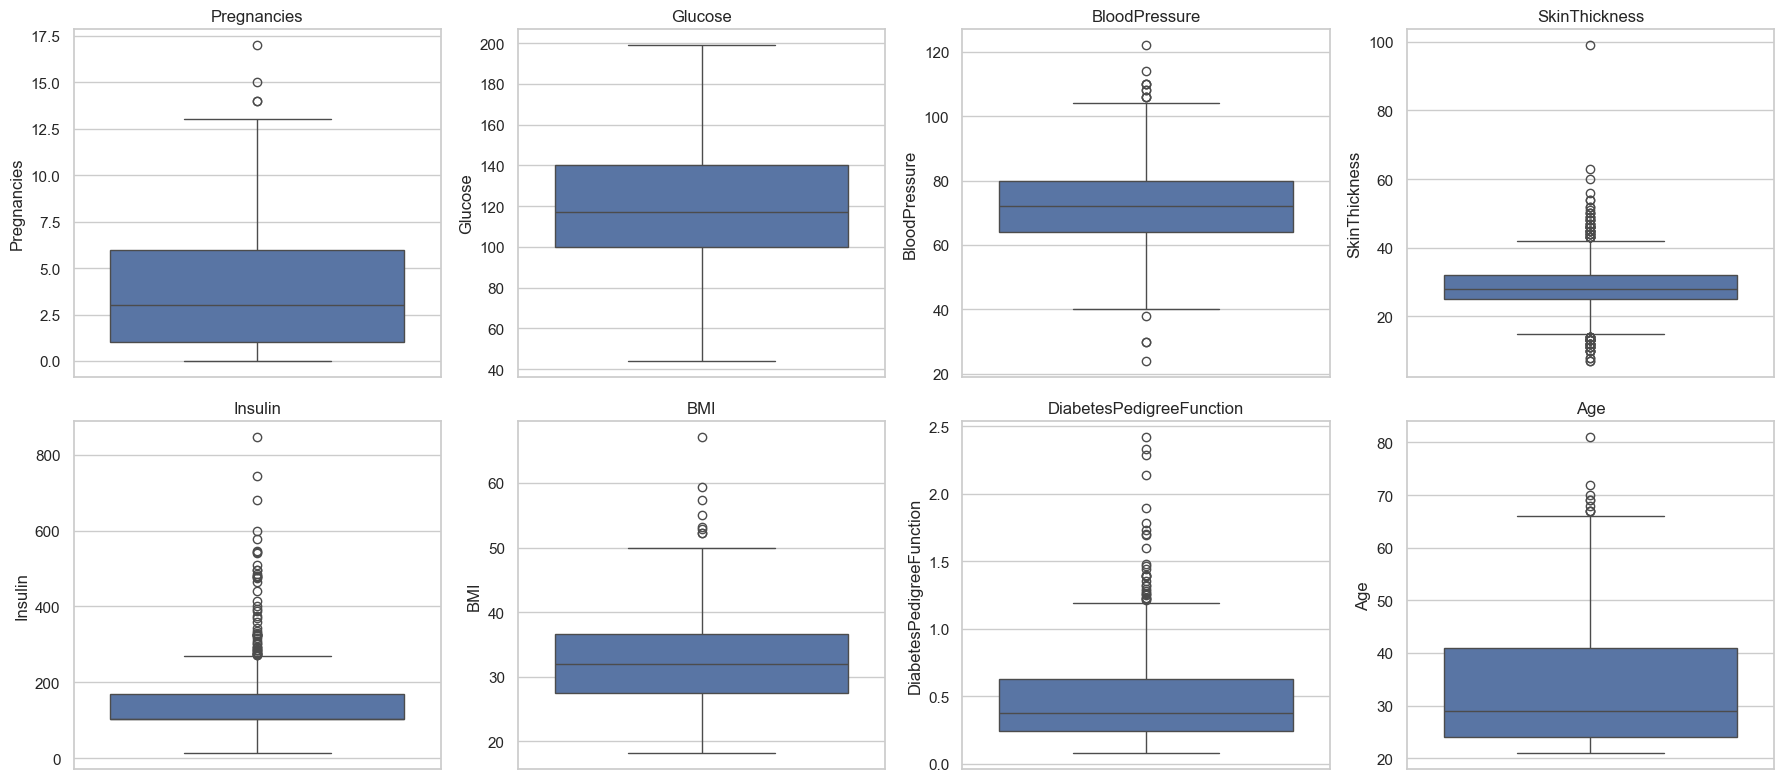

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), features):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [13]:
skewness = df[features].skew().sort_values(ascending=False)
skewness

Insulin                     3.028046
DiabetesPedigreeFunction    1.919911
Age                         1.129597
Pregnancies                 0.901674
SkinThickness               0.817477
BMI                         0.606416
Glucose                     0.532324
BloodPressure               0.140830
dtype: float64

## 4. Outcome별 비교 (Bivariate: feature vs target)

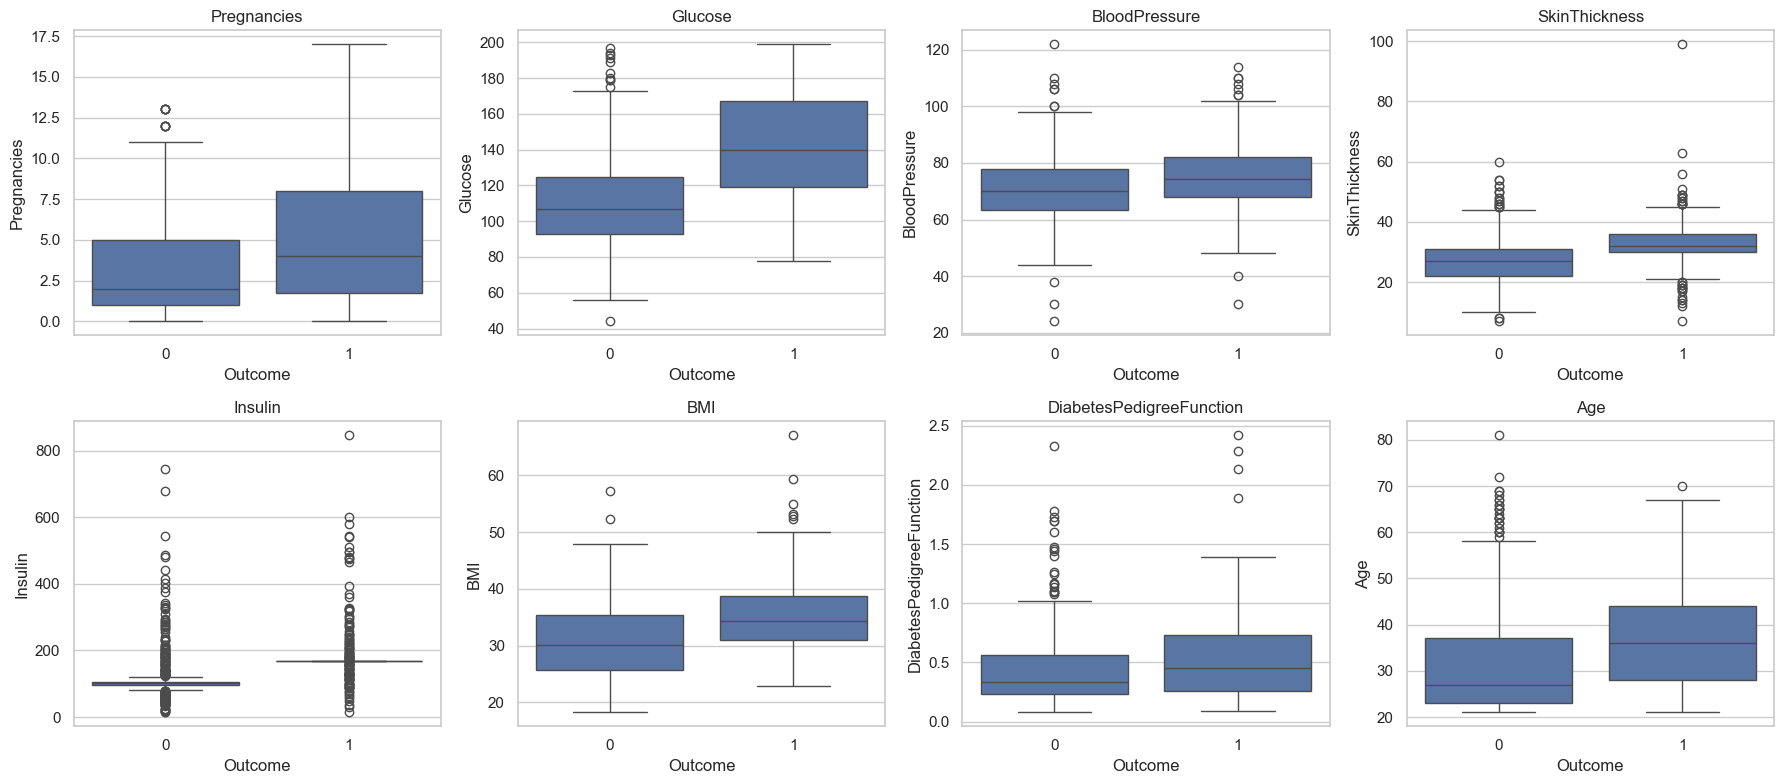

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), features):
    sns.boxplot(data=df, x='Outcome', y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [15]:
df.groupby('Outcome')[features].mean().T

Outcome,0,1
Pregnancies,3.298000,4.865672
Glucose,110.622000,142.302239
BloodPressure,70.844000,75.272388
SkinThickness,27.170000,32.671642
Insulin,117.172000,187.615672
BMI,30.846000,35.398507
DiabetesPedigreeFunction,0.429734,0.550500
Age,31.190000,37.067164


### 임상적으로 중요한 변수 자세히 보기 (Glucose, BMI, Age)

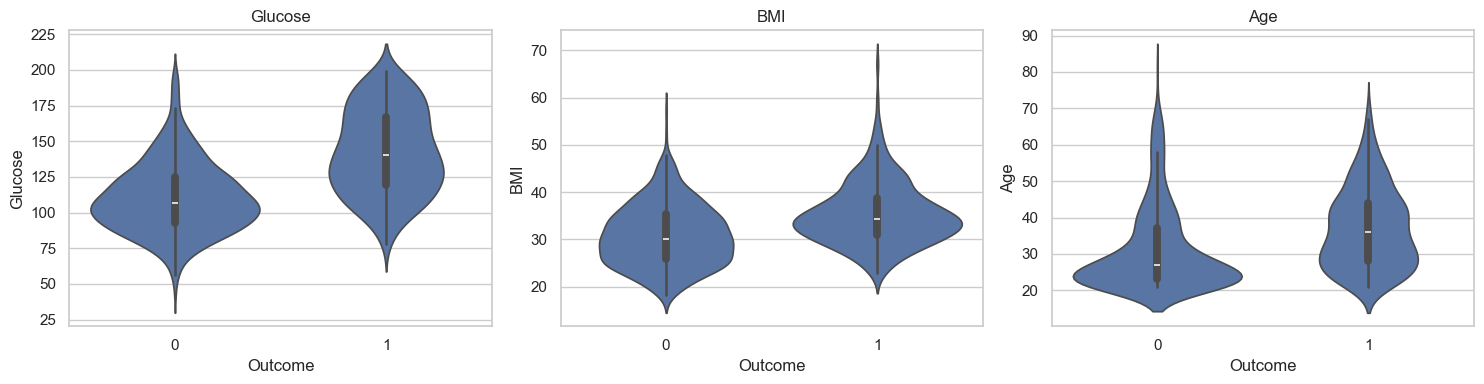

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Glucose', 'BMI', 'Age']):
    sns.violinplot(data=df, x='Outcome', y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 5. 피처 간 관계 (상관관계)

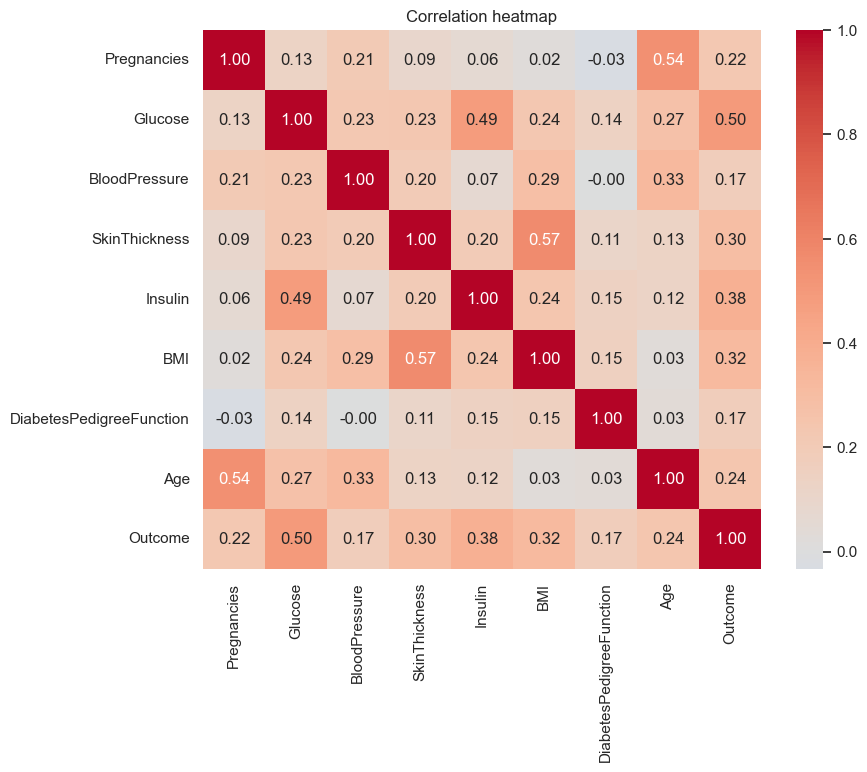

In [17]:
corr = df.corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation heatmap')
plt.show()

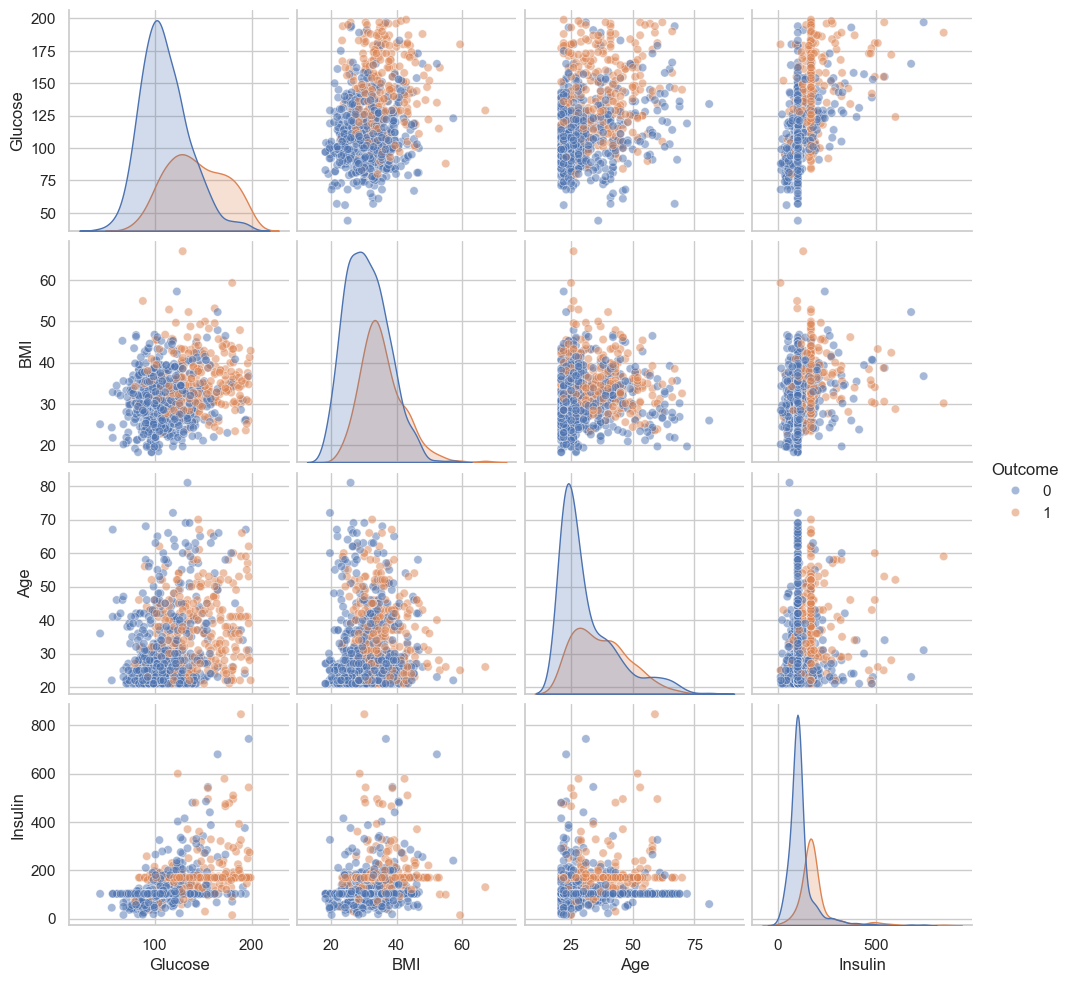

In [18]:
sns.pairplot(df, vars=['Glucose', 'BMI', 'Age', 'Insulin'], hue='Outcome', diag_kind='kde', plot_kws={'alpha': 0.5})
plt.show()

## 6. 트리 모델 관점의 시사점 정리

- **클래스 불균형**: Outcome 0/1이 약 65:35 → 학습 시 `class_weight` 조정 또는 Precision/Recall/F1/AUC 등 불균형에 강건한 지표로 평가 필요.
- **Insulin/SkinThickness 임퓨테이션 스파이크**: 그대로 사용할지, 해당 값이 대체값임을 나타내는 이진 플래그 피처를 추가할지는 모델링 단계에서 결정. 트리 모델은 스케일에 민감하지 않으므로 정규화는 불필요.
- **Outcome별로 분포 차이가 뚜렷한 피처**: Glucose, BMI, Age는 그룹 간 차이가 커서 트리 분할에 유용할 후보로 보인다. 상관관계 히트맵과 groupby 평균 비교 결과를 참고해 우선순위를 정한다.
- **다중공선성**: 트리 모델은 상관된 피처에 영향을 크게 받지 않으므로 이번 단계에서는 제거하지 않고 참고만 한다.